# Telco Customer Churn Analysis

In [33]:
import pandas as pd
import matplotlib.pyplot as plt


file_path = r"C:\Users\HP\Desktop\kajal\Future Interns Projects\Project2_TelcoCustomerChurn\WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

print(df.head()) 

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [34]:
# Convert TotalCharges to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [35]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [36]:
print(df[['TotalCharges', 'tenure', 'MonthlyCharges']].isnull().sum())

TotalCharges      11
tenure             0
MonthlyCharges     0
dtype: int64


In [37]:
df = df.dropna(subset=['TotalCharges'])

In [38]:
print(df[['TotalCharges']].isnull().sum())

TotalCharges    0
dtype: int64


In [39]:
# Create New Tenure Group Columns
def tenure_group(tenure):
    if tenure <= 12:
        return "New"
    elif tenure <= 24:
        return "Growing"
    elif tenure <= 48:
        return "Loyal"
    else:
        return "Long-terms"
df['TenureGroup'] = df['tenure'].apply(tenure_group)
print(df['TenureGroup'].value_counts())


TenureGroup
Long-terms    2239
New           2175
Loyal         1594
Growing       1024
Name: count, dtype: int64


## Key Metrics to Calculate

#### KPI 1 — Total Customers

In [40]:
customer_count = df['customerID'].nunique()

print("Total Customers:", customer_count)

Total Customers: 7032


#### KPI 2 — Total Churned Customers

In [41]:
total_churned = df[df['Churn'] == "Yes"]['customerID'].nunique()
print("Total Churned Customers: ",total_churned)

Total Churned Customers:  1869


#### KPI 3 — Churn Rate

In [42]:
churn_rate = round((total_churned / customer_count) * 100, 2)

print("Churn Rate (%):", churn_rate)

Churn Rate (%): 26.58


#### KPI 4 — Avg Monthly Charges

In [43]:
avg_monthly_charge = round(df['MonthlyCharges'].mean(),2)
print("Average Monthly Charges:", avg_monthly_charge)

Average Monthly Charges: 64.8


### Churn by Contract Type

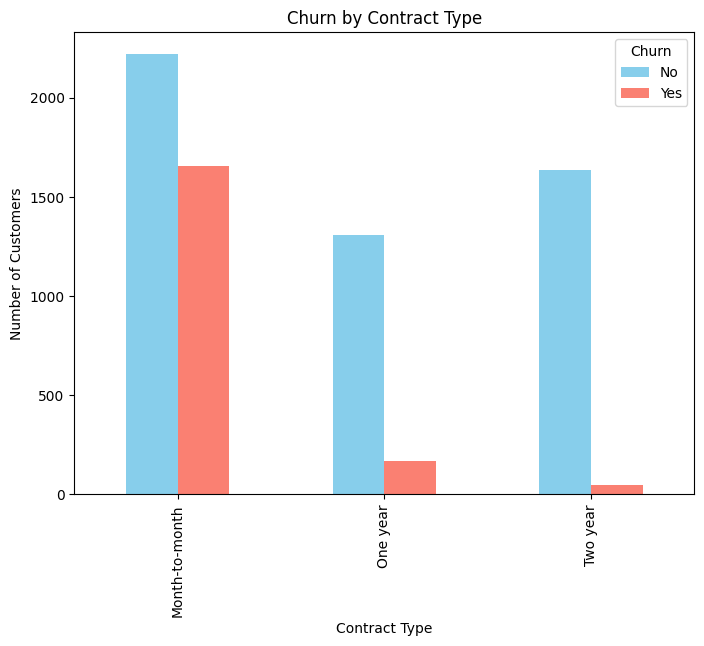

In [44]:
churn_by_contract = df.groupby(['Contract', 'Churn']).size().unstack()

# Plot
churn_by_contract.plot(kind='bar', stacked=False, figsize=(8,6), color=['skyblue','salmon'])
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()


### Churn by Tenure

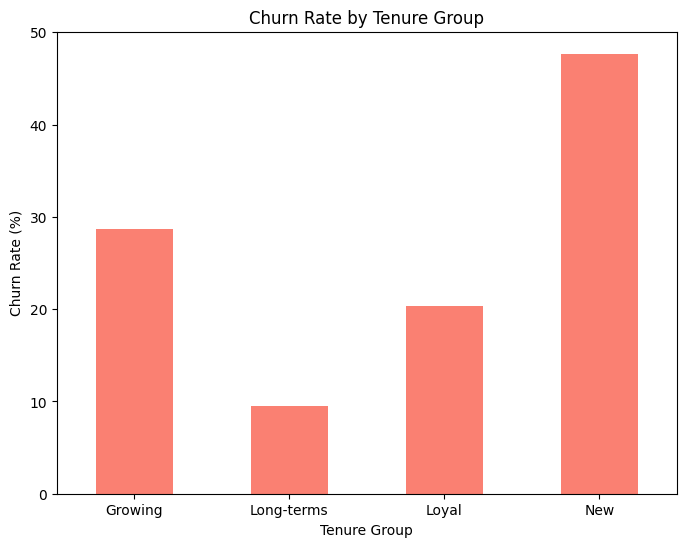

In [45]:
# Convert Churn column to numeric (Yes=1, No=0)
df['Churn_Flag'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Calculate churn rate by tenure group (without lambda)
churn_by_group = df.groupby('TenureGroup')['Churn_Flag'].mean() * 100

# Plot bar chart
plt.figure(figsize=(8,6))
churn_by_group.plot(kind='bar', color='salmon')
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()


### Churn by Payment Method

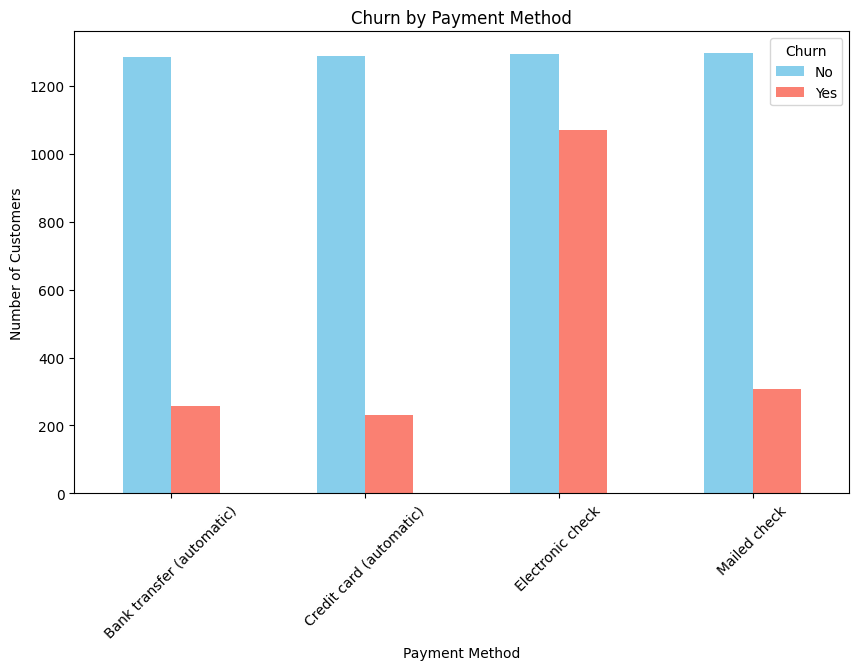

In [46]:
# Count churn by payment method
churn_by_payment = df.groupby(['PaymentMethod', 'Churn']).size().unstack()

# Plot grouped bar chart
churn_by_payment.plot(kind='bar', stacked=False, figsize=(10,6), color=['skyblue','salmon'])
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.xticks(rotation=45)
plt.show()


### Churn by Monthly Charges

C:\Users\HP\AppData\Local\Temp\ipykernel_27452\3284802601.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_charges = df.groupby('MonthlyCharges_Group')['Churn_Flag'].mean() * 100


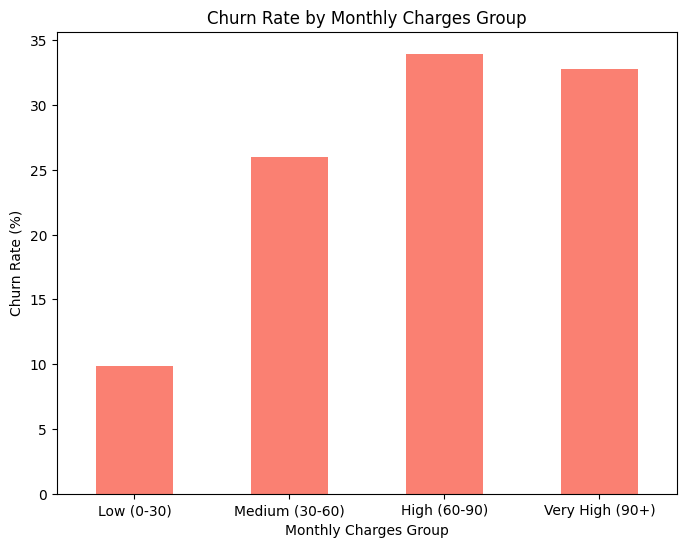

In [47]:
# Convert Churn column to numeric (Yes=1, No=0)
df['Churn_Flag'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Calculate churn rate by MonthlyCharges bins
bins = [0, 30, 60, 90, 120]   # adjust ranges as needed
labels = ['Low (0-30)', 'Medium (30-60)', 'High (60-90)', 'Very High (90+)']
df['MonthlyCharges_Group'] = pd.cut(df['MonthlyCharges'], bins=bins, labels=labels, include_lowest=True)

churn_by_charges = df.groupby('MonthlyCharges_Group')['Churn_Flag'].mean() * 100

# Plot bar chart
plt.figure(figsize=(8,6))
churn_by_charges.plot(kind='bar', color='salmon')
plt.title("Churn Rate by Monthly Charges Group")
plt.xlabel("Monthly Charges Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()


In [49]:
df.to_excel("Clean_TelcoCustomerChurn.xlsx", index=False)